In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from cycler import cycler

from data_processing.utils_snp.md_output_parser import MDVideoOutputParser
from data_processing.utils_snp.db_utils import load_database

In [2]:
# util function
def plot_frequencies(annotated_tracklets_df, col_name):
    fig, ax = plt.subplots(1,1, figsize=(12,8))
    
    if isinstance(col_name, list):
            df = pd.concat([
                annotated_tracklets_df
                .groupby(col)
                .agg({"event_id": pd.Series.nunique})
                for col in col_name], axis=0)
            attributes_df = df.groupby(level=0).sum().sort_values("event_id", ascending=False)
    else:
        attributes_df = (
            annotated_tracklets_df
            .groupby(col_name)
            .agg({"event_id": pd.Series.nunique})
            .sort_values("event_id", ascending=False)
        )

    attributes_df["perc"] = attributes_df["event_id"] * 100 / attributes_df["event_id"].sum()

    
    attributes_df[["event_id"]].plot(kind="bar", width=0.8, edgecolor="k", ax=ax)
    
    ax.set_xticklabels(attributes_df.index.to_list(), rotation=30, ha="right")
    plt.grid(axis="y")
    
    # Add percentage text on each bar
    for i, (idx, row) in enumerate(attributes_df.iterrows()):
        bar = ax.patches[i]
        height = bar.get_height() + 2
        perc = "<1" if row["perc"] < 1.0 else f'{row["perc"]:.1f}'
        color = "red" if row["event_id"] <= 5 else "black"
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            height, 
            f'{row["event_id"]:.0f}\n({perc})%', 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            color=color
        )
    ax.set_ylim(0, attributes_df["event_id"].max() + 20)
    ax.get_legend().set_visible(False)
    plt.show()

    return attributes_df

# Figure aesthetics
mpl_config = {
    "figure.figsize": (12, 8),
    "figure.dpi": 100,
    "figure.facecolor": "white",

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 15,

    # Title and Label size
    "axes.titlesize": 20,
    "axes.labelsize": 15,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Grid and Spines for readability
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,

    # Legend
    "legend.fontsize": 12,
    "legend.frameon": True,
    "legend.loc": "best",
}

plt.rcParams.update(mpl_config)

# 2024

In [3]:
cmap = plt.get_cmap('Blues_r')
colors = [cmap(i) for i in np.linspace(0.5, 0.7, 3)]  # Sample 7 colors

# Apply the configuration
plt.rcParams.update({"axes.prop_cycle": cycler(color=colors)})

In [4]:
# Load annotations in JSON format
annotated_tracklets_folder = Path("/media/EVO870/datasets/SNP_Summer_2024/experiments/Data_Processing_2024/annotated_tracklets_json")
database_path = Path("/media/EVO870/datasets/SNP_Summer_2024/database.db")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)

annotated_tracklets_df = md_parser.to_dataframe()
annotated_tracklets_df = annotated_tracklets_df[annotated_tracklets_df["is_annotated"] != False]
annotated_tracklets_df.sample(2)

,frame_id,detections,file_id,detection_file_path,max_detection_conf,conf,category,track_id,bbox,outside,occluded,is_annotated,attributes.Action,attributes.Action2,attributes.Activity,attributes.Deer_adult_sex,attributes.Deer_age,attributes.Species
365039,163,"{'conf': 0.9097025990486145, 'category': 0, 't...",S1_C1_E269_V0263,S1/C1/S1_C1_E269_V0263.json,NaN,0.909703,0.0,2.0,"[0.629687488079071, 0.5222222208976746, 0.0786...",0,False,True,grazing,none,foraging,female,adult,red_deer
689333,1778,NaN,S2_C3_E602_V0141,S2/C3/S2_C3_E602_V0141.json,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Add information about datetime and event id
conn = load_database(database_path, "Data_Processing_2024")
videos_metadata_df = pd.read_sql("SELECT * FROM Videos", con=conn)
conn.close()

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "frame_id", "is_annotated", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Deer_adult_sex", "attributes.Deer_age", "attributes.Species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_cam_id"]], on="file_id")
)
none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]
annotated_tracklets_df.sample(2)

,file_id,frame_id,is_annotated,attributes.action,attributes.action2,attributes.activity,attributes.deer_adult_sex,attributes.deer_age,attributes.species,event_id,date_time,site_cam_id
517909,S1_C2_E52_V0077,865,True,unknown,NaN,foraging,female,adult,red_deer,E52,2024-06-22 19:27:16,S1_C2
477671,S1_C2_E168_V0221,857,True,grazing,NaN,foraging,NaN,NaN,chamois,E168,2024-07-07 07:43:48,S1_C2


In [6]:
annotated_tracklets_df_2024 = annotated_tracklets_df.copy()

In [7]:
annotated_events_df = (
    annotated_tracklets_df
    .groupby("event_id")
    .agg({
        "attributes.action": lambda x: list(set(x)), 
        "attributes.action2": lambda x: list(set(x)), 
        "attributes.species": lambda x: list(set(x)), 
        "attributes.activity": lambda x: list(set(x)), 
        "attributes.deer_adult_sex": lambda x: list(set(x)), 
        "attributes.deer_age": lambda x: list(set(x)), 
        "date_time": "min"
    })
    .reset_index(drop=False)
)

annotated_events_df.sample(5)

,event_id,attributes.action,attributes.action2,attributes.species,attributes.activity,attributes.deer_adult_sex,attributes.deer_age,date_time
27,E182,[walking],[nan],[red_deer],[foraging],[female],[adult],2024-07-09 05:56:50
154,E536,"[unknown, sniffing, standing_head_down, browsi...",[nan],"[roe_deer, nan]","[vigilance, foraging, nan]","[male, nan]","[adult, nan]",2024-07-22 18:05:00
183,E590,"[running, nan, jumping]",[nan],"[nan, roe_deer]","[unknown, foraging, nan]","[male, nan]","[adult, nan]",2024-08-12 10:27:04
74,E334,"[unknown, walking, standing_head_down, grazing]",[nan],[red_deer],[foraging],[female],[adult],2024-07-29 03:06:56
229,E78,"[nan, jumping]",[nan],"[hare, nan]","[foraging, nan]",[nan],[nan],2024-06-25 06:43:14


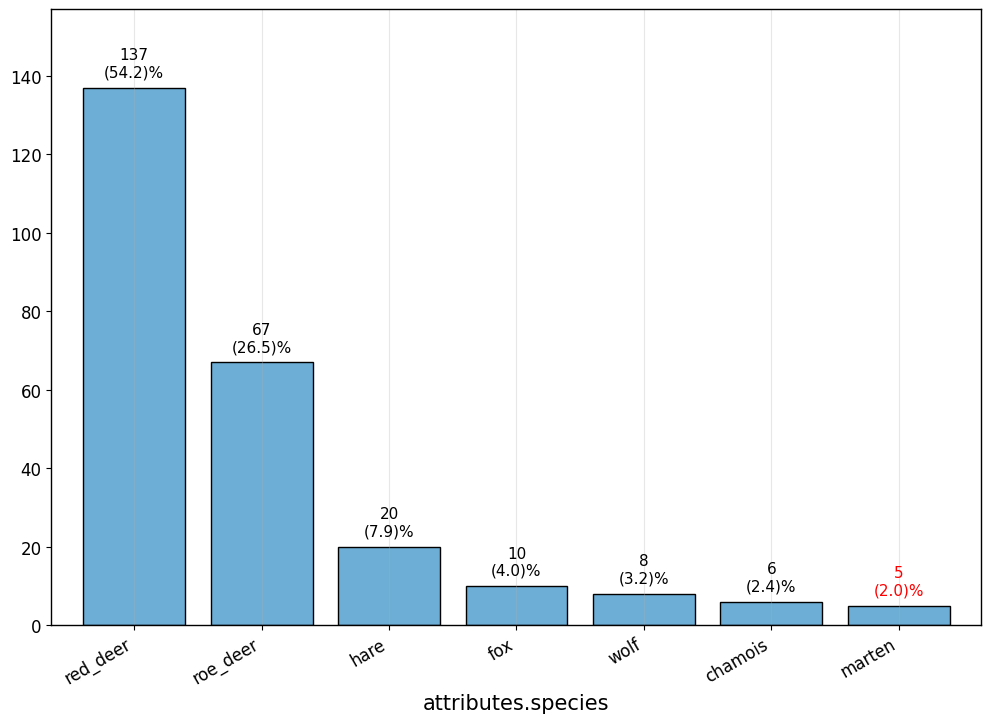

In [8]:
marten_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.species"] == "other_small_mammal"].index
annotated_tracklets_df.loc[marten_idx, "attributes.species"] = "marten"

species_df_2024 = plot_frequencies(annotated_tracklets_df, "attributes.species")

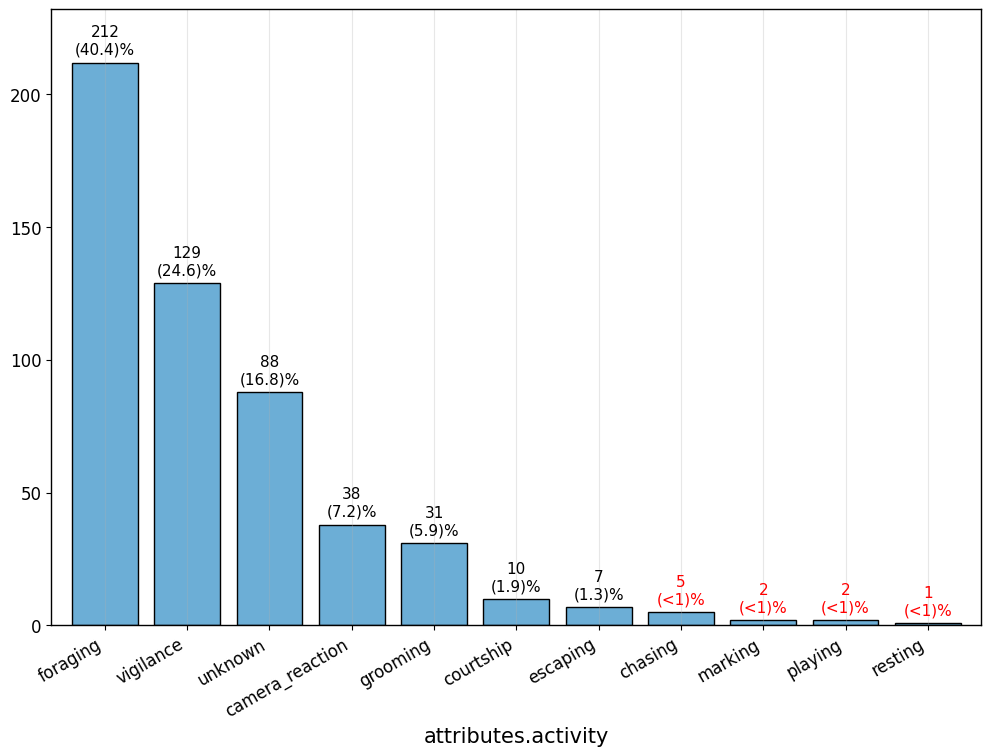

In [9]:
acty_df_2024 = plot_frequencies(annotated_tracklets_df, "attributes.activity")

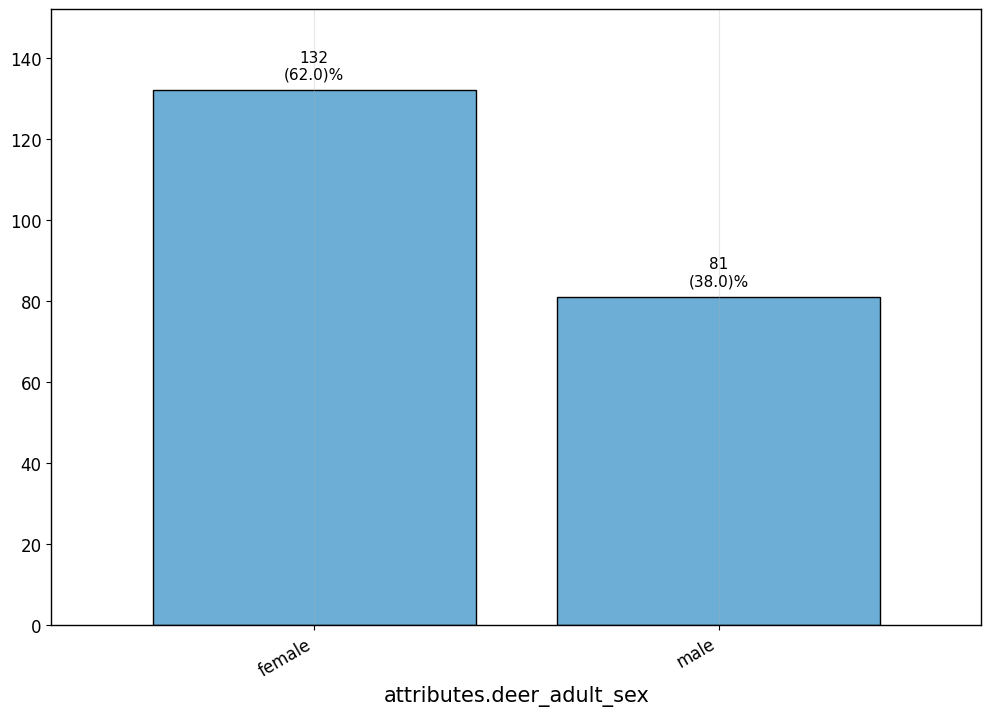

In [10]:
sex_df_2024 = plot_frequencies(annotated_tracklets_df, "attributes.deer_adult_sex")

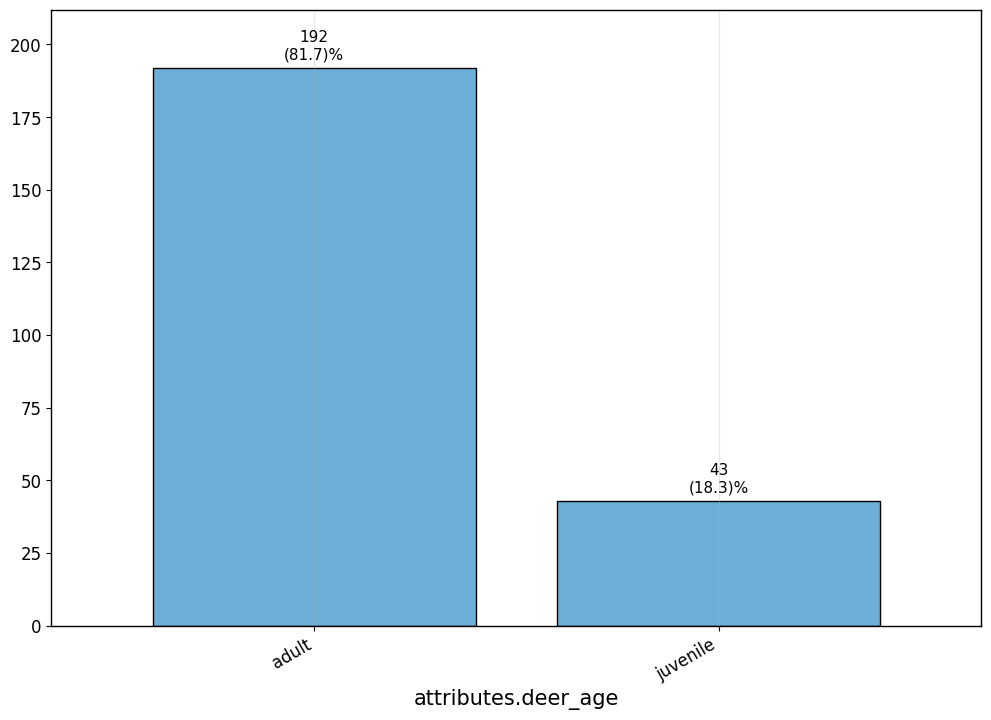

In [11]:
age_df_2024 = plot_frequencies(annotated_tracklets_df, "attributes.deer_age")

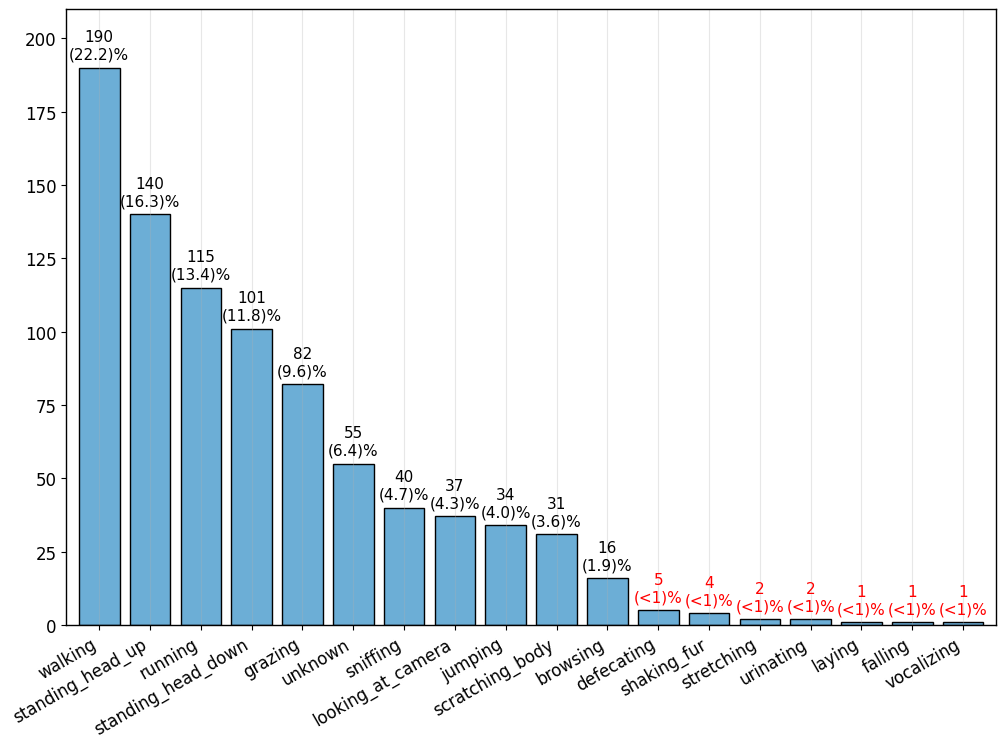

In [12]:
actn_df_2024 = plot_frequencies(annotated_tracklets_df, ["attributes.action", "attributes.action2"])

In [13]:
conn = load_database(database_path, "Data_Processing_2024")
tracklets_metadata_df = pd.read_sql("SELECT * FROM Tracklets", con=conn)
conn.close()

tracklets_metadata_df = tracklets_metadata_df.merge(videos_metadata_df[["event_id", "file_id", "date_time"]], on="file_id")
tracklets_metadata_df = tracklets_metadata_df[["tublet_file_id", "file_id", "event_id", "tublet_duration", "date_time"]]
tracklets_metadata_df.to_csv("/media/EVO870/datasets/SNP_Summer_2024/experiments/Data_Processing_2024/tracklets_tosplit.csv")

In [27]:
import json

with open("data_split_events.json", "r") as f:
    content = json.load(f)
    train_events = content["train"]
    test_events = content["test"]

event_dates_df = annotated_tracklets_df[["event_id", "date_time"]].drop_duplicates("event_id")
train_df = event_dates_df[event_dates_df["event_id"].isin(train_events)].sort_values(["date_time"])
test_df = event_dates_df[event_dates_df["event_id"].isin(test_events)].sort_values(["date_time"])

print(train_df)

       event_id            date_time
287120      E23  2024-06-18 08:37:52
704289     E464  2024-06-20 01:17:42
589140      E55  2024-06-23 14:17:58
244862      E65  2024-06-24 15:30:29
241197      E75  2024-06-25 06:02:14
694800     E474  2024-06-27 21:01:24
1835       E700  2024-07-02 00:32:18
716379     E498  2024-07-08 21:27:30
20910      E737  2024-07-09 21:19:32
65155      E200  2024-07-12 18:37:52
107849     E243  2024-07-18 19:33:00
23296      E863  2024-07-19 00:25:54
723204     E548  2024-07-29 23:28:52
683352     E555  2024-07-31 04:42:06
221324     E386  2024-08-02 16:14:56


In [ ]:
len(pd.to_datetime(test_df["date_time"]).dt.date.unique())

       event_id            date_time
723489     E475  2024-06-28 00:55:56
736359     E491  2024-07-04 20:25:12
271153     E163  2024-07-06 15:10:16
2370       E720  2024-07-07 03:16:53
131020     E168  2024-07-07 07:44:14
504710     E169  2024-07-07 08:06:28
1220       E746  2024-07-10 20:54:02
155690     E204  2024-07-13 00:47:06
358177     E230  2024-07-16 13:15:56
22120      E874  2024-07-23 04:38:24
736674     E568  2024-08-04 08:45:22
686577     E573  2024-08-06 20:02:38
753962     E594  2024-08-14 01:23:20


In [29]:
annotated_tracklets_df[annotated_tracklets_df["event_id"].isin(test_df["event_id"])].drop_duplicates("file_id").groupby("event_id").count()

,file_id,frame_id,is_annotated,attributes.action,attributes.action2,attributes.activity,attributes.deer_adult_sex,attributes.deer_age,attributes.species,date_time,site_cam_id
event_id,,,,,,,,,,,
E163,2,2,2,2,0,2,2,2,2,2,2
E168,3,3,3,3,0,3,0,0,3,3,3
E169,1,1,1,1,0,1,0,0,1,1,1
E204,34,34,32,32,0,32,32,32,32,34,34
E230,1,1,1,1,0,1,0,0,1,1,1
E475,1,1,0,0,0,0,0,0,0,1,1
E491,1,1,0,0,0,0,0,0,0,1,1
E568,3,3,3,3,0,3,1,3,3,3,3
E573,3,3,2,2,0,2,2,2,2,3,3


In [52]:
annotated_events_df[annotated_events_df["event_id"]=="E874"]["attributes.activity"].values

array([list(['chasing', 'escaping'])], dtype=object)

In [53]:
annotated_tracklets_df[annotated_tracklets_df["attributes.activity"] == "escaping"].drop_duplicates("event_id")[["event_id", "date_time"]]

,event_id,date_time
22120,E874,2024-07-23 04:38:24
134096,E168,2024-07-07 07:44:14
221324,E386,2024-08-02 16:14:56
233712,E131,2024-07-03 17:39:58
271153,E163,2024-07-06 15:10:16
686577,E573,2024-08-06 20:02:38
754423,E537,2024-07-23 05:27:24


# 2023

In [37]:
cmap = plt.get_cmap('Greens_r')
colors = [cmap(i) for i in np.linspace(0.5, 0.7, 3)]  # Sample 7 colors

# Apply the configuration
plt.rcParams.update({"axes.prop_cycle": cycler(color=colors)})

# Load annotations in JSON format
annotated_tracklets_folder = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/SNP_Summer_2023_annotated_species_tracks")
database_path = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/raw_videos_metadata.csv")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)

annotated_tracklets_df = md_parser.to_dataframe()
annotated_tracklets_df.sample(2)

,frame_id,max_detection_conf,detections,width,height,file_id,detection_file_path,conf,category,track_id,...,attributes.Action2,attributes.Activity,attributes.red_deer_age_group,attributes.red_deer_adult_sex,attributes.species,outside,attributes.Interacting,attributes.Species,attributes.Sex,attributes.Age group
397570,1382,0.961,"{'conf': 0.9610000252723694, 'category': 1, 't...",1920,1080,S1_C2_E195_V0440,S1/C2/S1_C2_E195_V0440_tracks.frames.json,0.961,1.0,1.0,...,none,foraging,adult,male,red_deer,NaN,NaN,NaN,NaN,NaN
276714,2156,0.000,NaN,1920,1080,S1_C2_E49_V0075,S1/C2/S1_C2_E49_V0075_tracks.frames.json,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
videos_metadata_df = pd.read_csv(database_path)

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "frame_id", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.red_deer_age_group", "attributes.red_deer_adult_sex", "attributes.species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_id", "cam_id"]], on="file_id")
)

none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]
annotated_tracklets_df = annotated_tracklets_df.rename(columns={"attributes.red_deer_age_group": "attributes.deer_age","attributes.red_deer_adult_sex":"attributes.deer_adult_sex"})
annotated_tracklets_df["attributes.deer_age"] = annotated_tracklets_df["attributes.deer_age"].str.replace("young", "juvenile")
annotated_tracklets_df["attributes.action"] = annotated_tracklets_df["attributes.action"].str.replace("none", "unknown")
annotated_tracklets_df["attributes.activity"] = annotated_tracklets_df["attributes.activity"].str.replace("none", "unknown")

annotated_tracklets_df.sample(2)

,file_id,frame_id,attributes.action,attributes.action2,attributes.activity,attributes.deer_age,attributes.deer_adult_sex,attributes.species,event_id,date_time,site_id,cam_id
339962,S1_C2_E121_V0189,315,standing_head_up,NaN,vigilance,adult,male,red_deer,E121,2023-09-11 20:20:26,S1,C2
542502,S2_C2_E378_V0121,1011,running,NaN,unknown,adult,male,red_deer,E378,2023-09-29 08:45:20,S2,C2


In [39]:
annotated_tracklets_df_2023 = annotated_tracklets_df.copy()

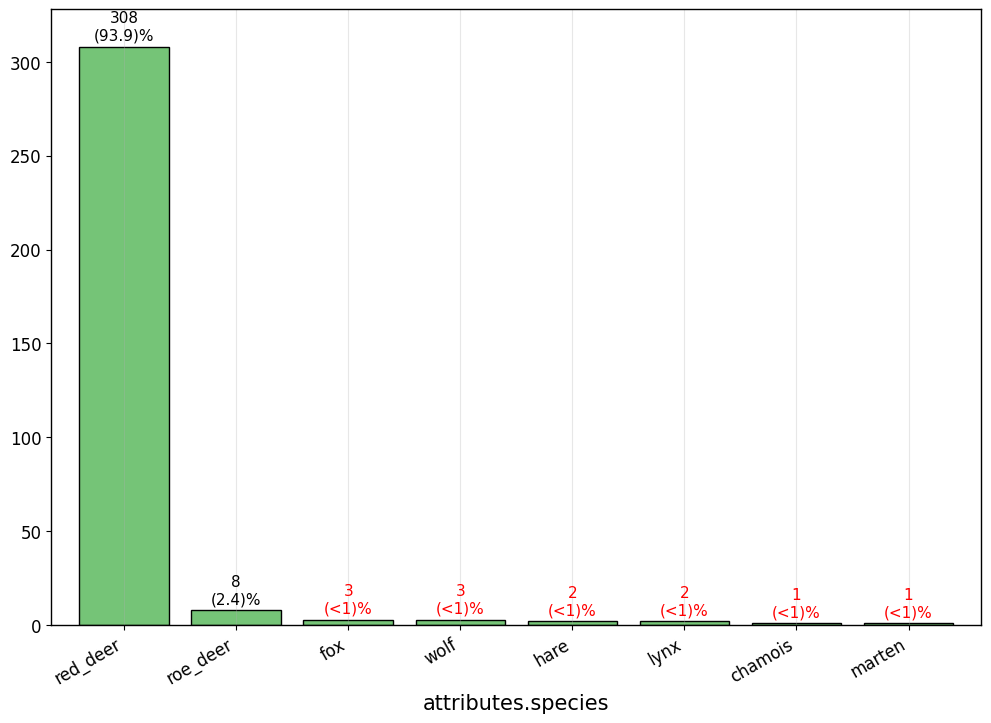

In [14]:
hare_idx = annotated_tracklets_df[(annotated_tracklets_df["attributes.species"] == "unknown") | (annotated_tracklets_df["file_id"] == "S1_C1_E51_V0116")].index # hare
marten_idx = annotated_tracklets_df[annotated_tracklets_df["file_id"] == "S2_C2_E318_V0068"].index

annotated_tracklets_df.loc[hare_idx, "attributes.species"] = "hare"
annotated_tracklets_df.loc[marten_idx, "attributes.species"] = "marten"

species_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.species")

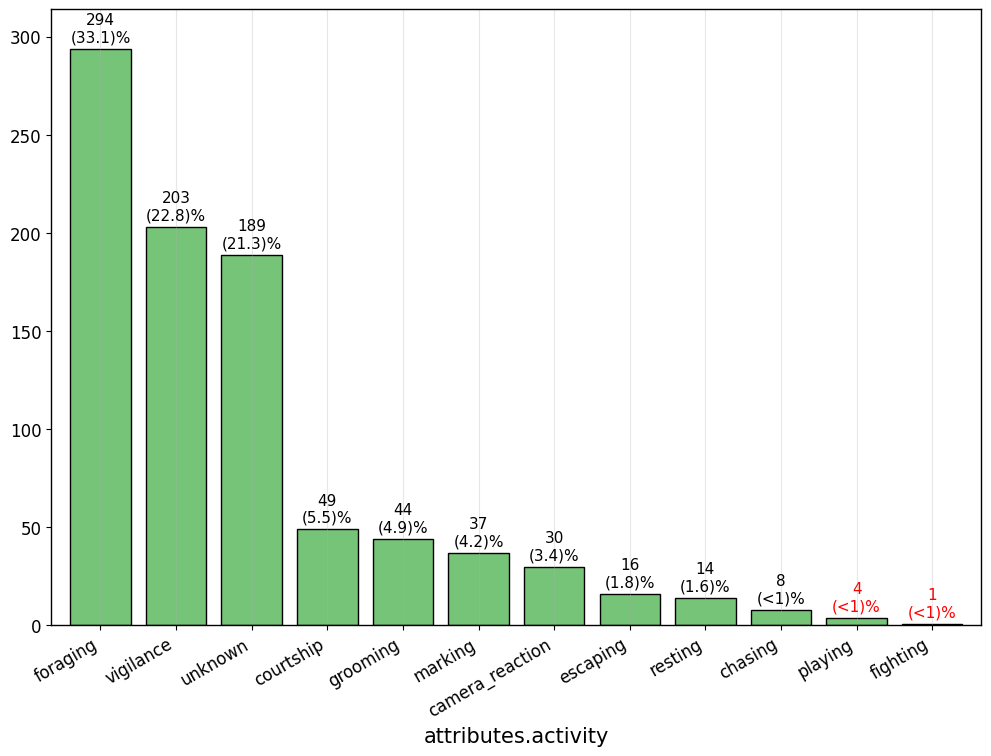

In [15]:
acty_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.activity")

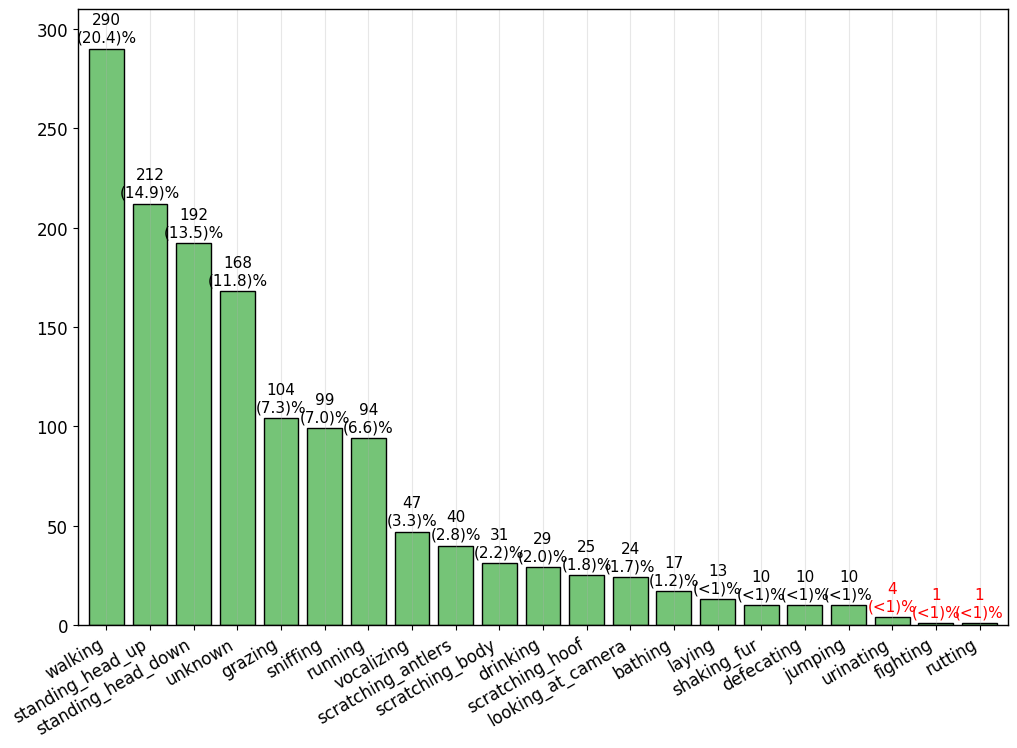

In [16]:
actn_df_2023 = plot_frequencies(annotated_tracklets_df, ["attributes.action", "attributes.action2"])

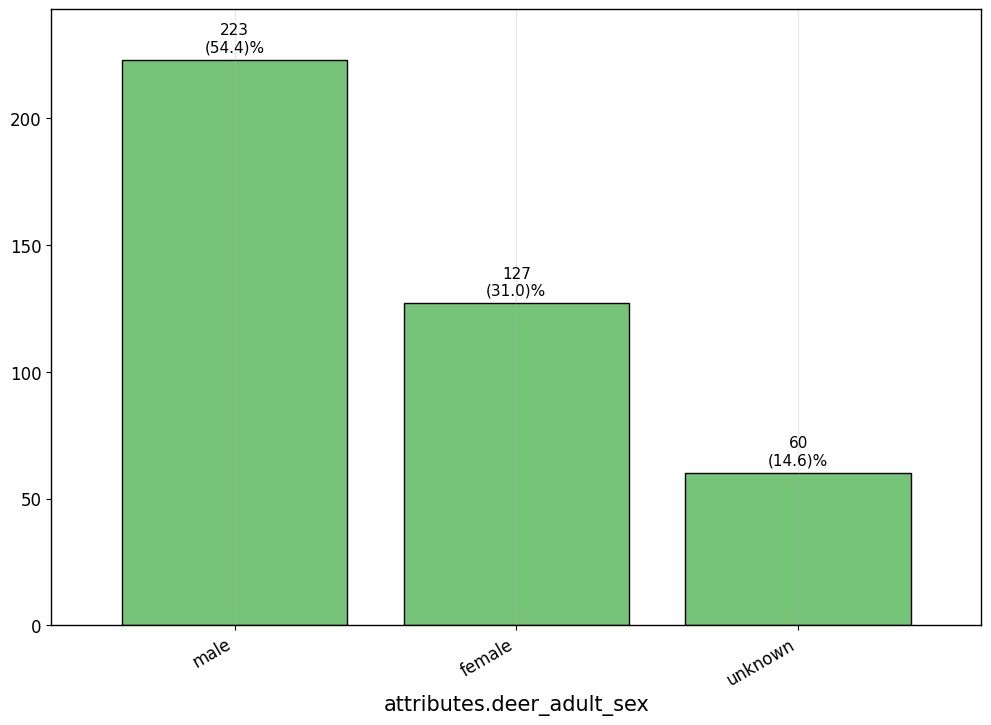

In [17]:
sex_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.deer_adult_sex")

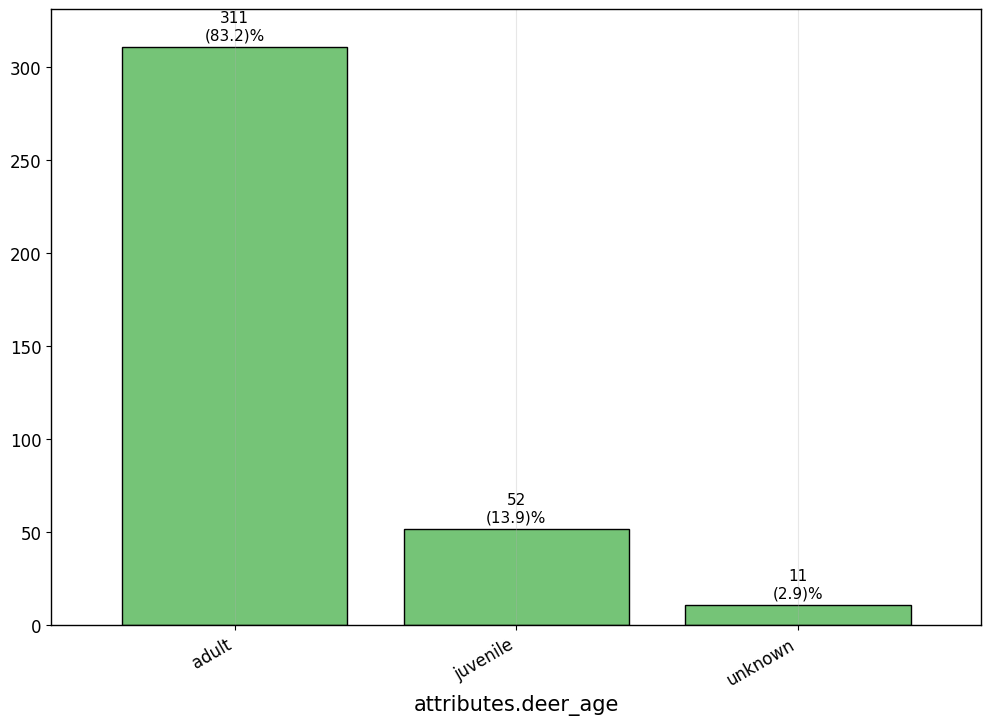

In [18]:
age_df_2023 = plot_frequencies(annotated_tracklets_df, "attributes.deer_age")

# Total

In [26]:
def plot_multi_season_frequencies(dfs: list[pd.DataFrame], col_name: str, log=False):

    fig, ax = plt.subplots(1,1, figsize=(12,8))

    total_df = pd.concat(dfs, axis=0)
    total_df = total_df.reset_index().groupby([col_name, "year"]).sum().unstack().fillna(0)
    total_df["total"] = total_df[("event_id", 2023)] + total_df[("event_id", 2024)]
    total_df = total_df.sort_values("total", ascending=False)
    total_df["perc"] = total_df["total"] * 100 / total_df["total"].sum()

    cmap_full = plt.get_cmap("GnBu")
    colors = [cmap_full(i) for i in np.linspace(0.25, 0.8, 2)]
    custom_cmap = ListedColormap(colors)

    total_df[["event_id"]].plot(kind="bar", width=0.8, edgecolor="k", ax=ax, stacked=True, cmap=custom_cmap, logy=log)
    
    ax.set_xticklabels(total_df.index.to_list(), rotation=30, ha="right")
    plt.grid(axis="y")
        
    # Add percentage text on each bar
    for i, (idx, row) in enumerate(total_df[["total", "perc"]].iterrows()):
        bar = ax.patches[i]
        height = row["total"].values[0] + 2
        perc = "<1" if row["perc"].values[0] < 1.0 else f'{row["perc"].values[0]:.1f}'
        color = "red" if row["total"].values[0] <= 5 else "black"
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            height, 
            f'{row["total"].values[0]:.0f}\n({perc})%', 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            color=color
        )

    ax.set_ylim(0.9, total_df["total"].max() + 40)
    plt.legend(["2023", "2024"])
    
    plt.show()

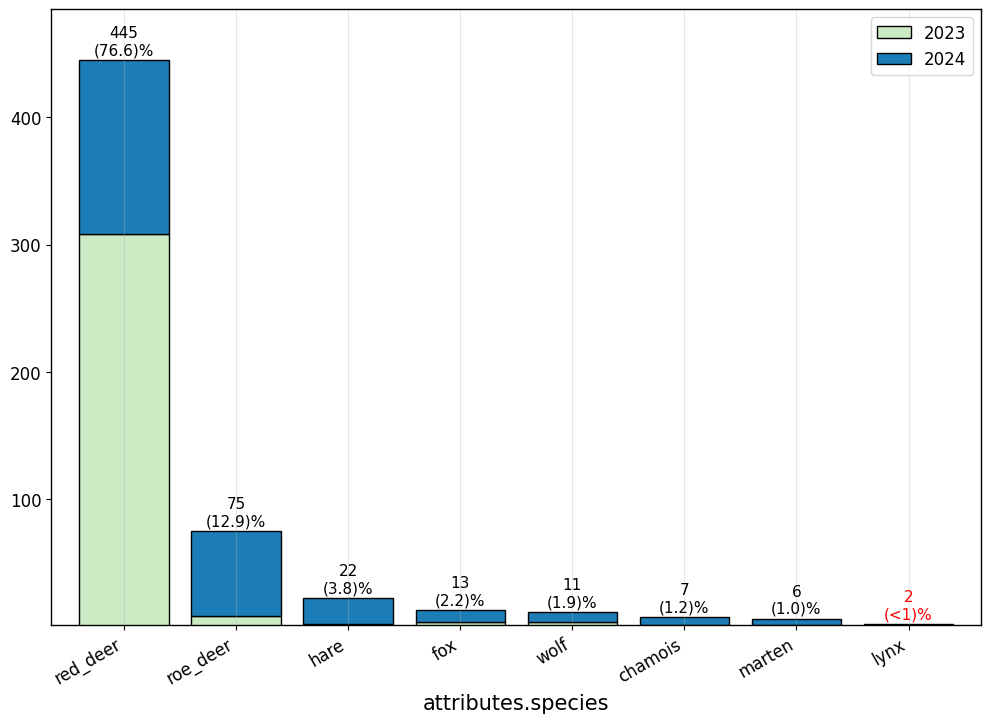

In [27]:
species_df_2023["year"] = 2023
species_df_2024["year"] = 2024
plot_multi_season_frequencies([species_df_2023.drop("perc", axis=1), species_df_2024.drop("perc", axis=1)], "attributes.species")

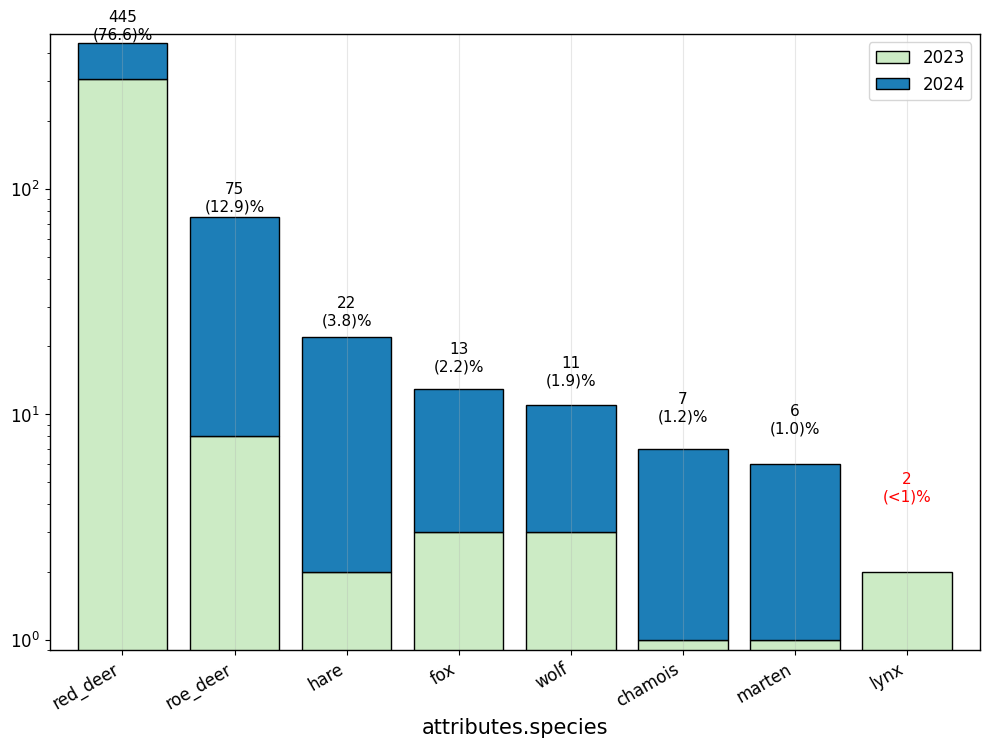

In [28]:
species_df_2023["year"] = 2023
species_df_2024["year"] = 2024
plot_multi_season_frequencies([species_df_2023.drop("perc", axis=1), species_df_2024.drop("perc", axis=1)], "attributes.species", log=True)

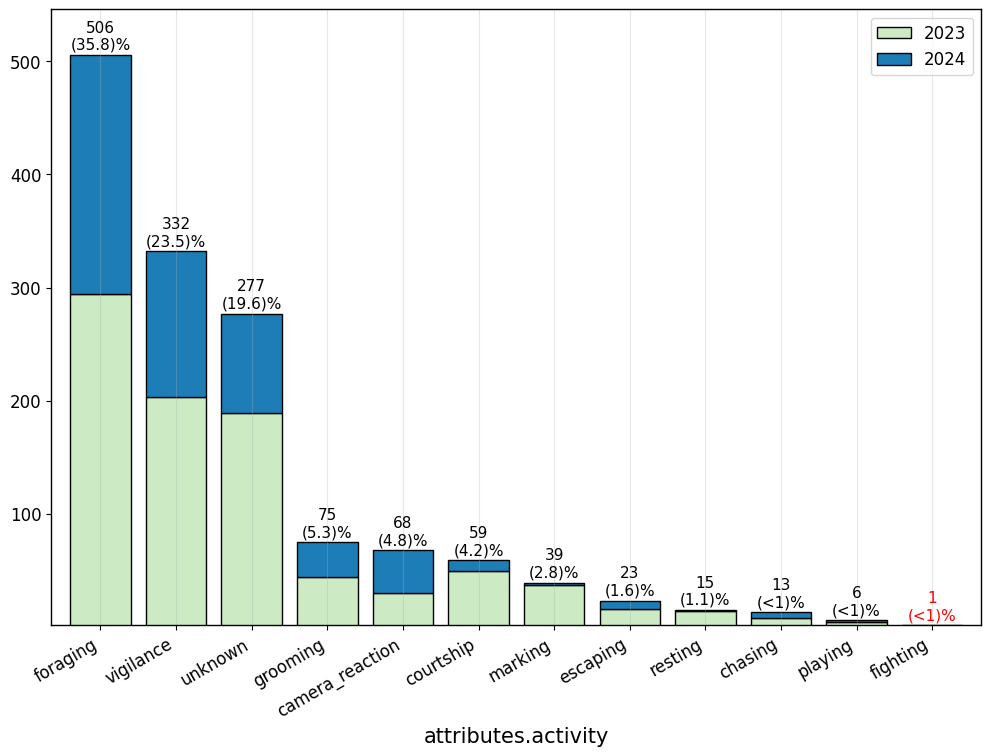

In [22]:
acty_df_2023["year"] = 2023
acty_df_2024["year"] = 2024
plot_multi_season_frequencies([acty_df_2023.drop("perc", axis=1), acty_df_2024.drop("perc", axis=1)], "attributes.activity")

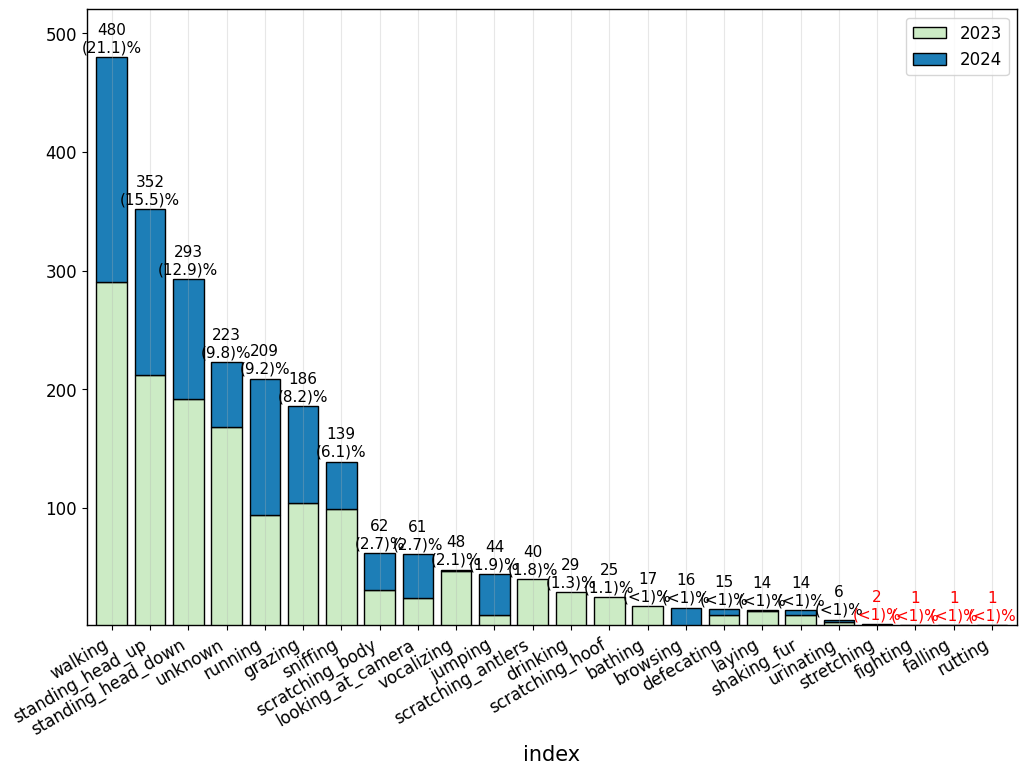

In [23]:
actn_df_2023["year"] = 2023
actn_df_2024["year"] = 2024
plot_multi_season_frequencies([actn_df_2023.drop("perc", axis=1), actn_df_2024.drop("perc", axis=1)], "index")

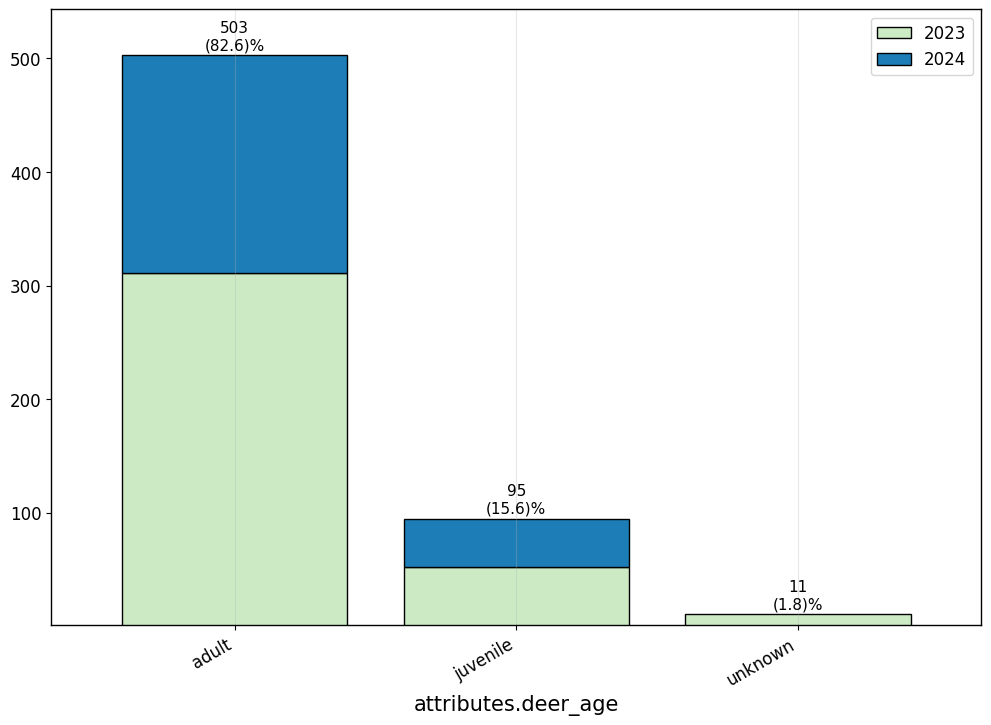

In [24]:
age_df_2023["year"] = 2023
age_df_2024["year"] = 2024
plot_multi_season_frequencies([age_df_2023.drop("perc", axis=1), age_df_2024.drop("perc", axis=1)], "attributes.deer_age")

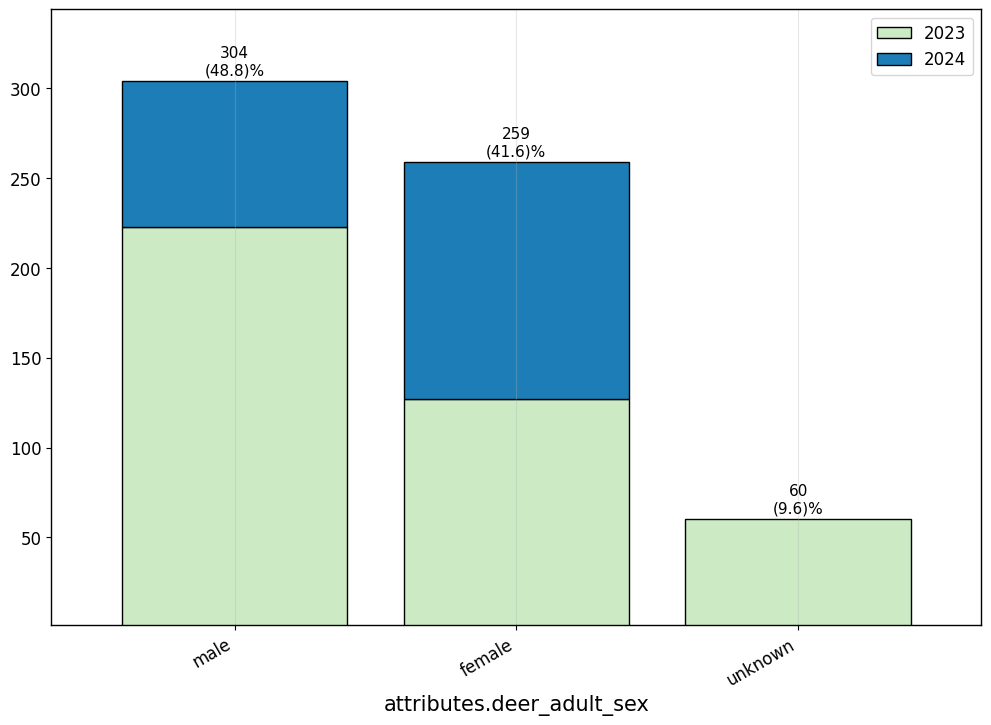

In [25]:
sex_df_2023["year"] = 2023
sex_df_2024["year"] = 2024
plot_multi_season_frequencies([sex_df_2023.drop("perc", axis=1), sex_df_2024.drop("perc", axis=1)], "attributes.deer_adult_sex")

In [42]:
annotated_tracklets_df_2024["site_id"] = annotated_tracklets_df_2024["site_cam_id"].apply(lambda d: d.split("_")[0])
annotated_tracklets_df_2024["cam_id"] = annotated_tracklets_df_2024["site_cam_id"].apply(lambda d: d.split("_")[1])

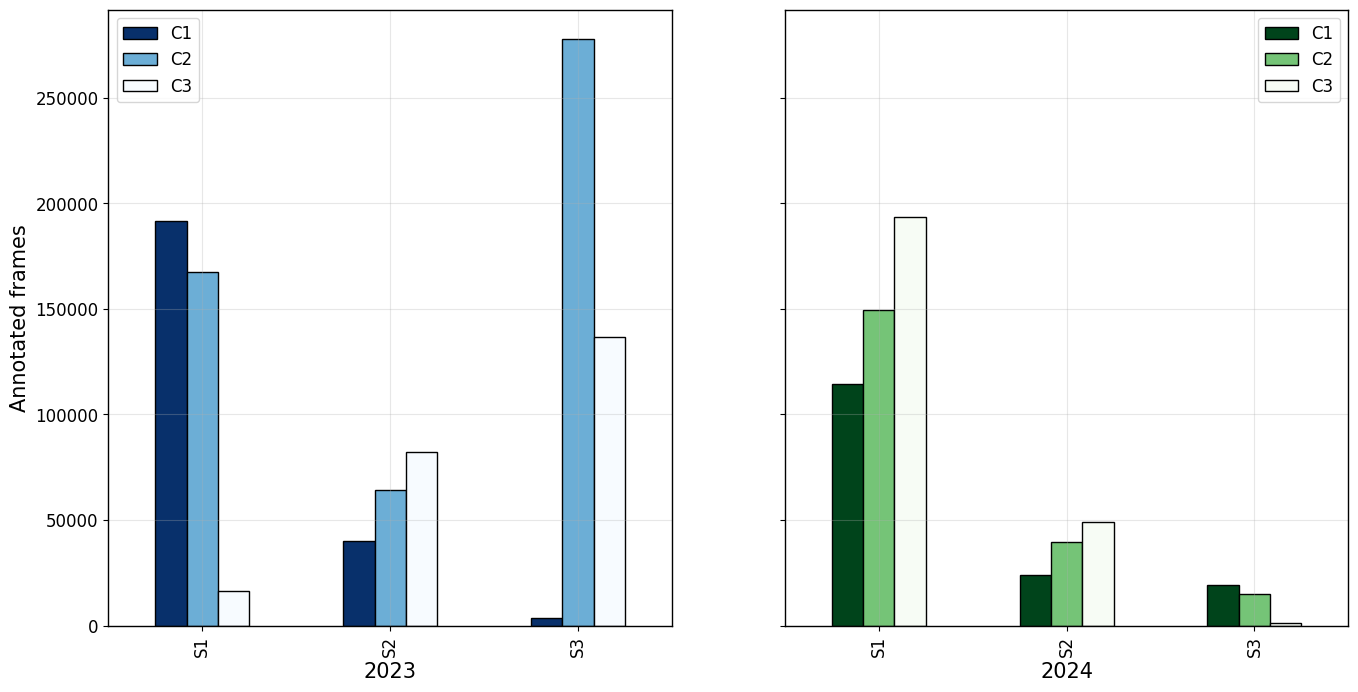

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

df1 = annotated_tracklets_df_2023.dropna(subset="attributes.species").groupby(["site_id", "cam_id"]).agg({"frame_id": "count"}).unstack()
df2 = annotated_tracklets_df_2024.dropna(subset="attributes.species").groupby(["site_id", "cam_id"]).agg({"frame_id": "count"}).unstack()

# Plot first bar
df1.plot(kind="bar", edgecolor="k", ax=axs[0], cmap="Blues_r")
# Plot second bar, slightly offset
df2.plot(kind="bar", edgecolor="k", ax=axs[1], cmap="Greens_r")
axs[0].legend(["C1", "C2", "C3"])
axs[1].legend(["C1", "C2", "C3"])

axs[0].set_ylabel("Annotated frames")
axs[0].set_xlabel("2023")
axs[1].set_xlabel("2024")


plt.show()

## Camera reactions

In [ ]:
cam_reaction_frames = annotated_tracklets_df[annotated_tracklets_df["attributes.Activity"] == "camera_reaction"][["file_id", "attributes.Action", "attributes.Action2", "attributes.Activity"]]
cam_reaction_frames["actions"] = cam_reaction_frames.apply(lambda d: (d["attributes.Action"], d["attributes.Action2"]), axis=1)
cam_reaction_frames["event_id"] = cam_reaction_frames["file_id"].apply(lambda d: d.split("_")[2])
cam_reaction_frames.groupby("actions").agg({"attributes.Activity": "count", "file_id": np.unique}).sort_values("attributes.Activity")

,attributes.Activity,file_id
actions,,
"(running, looking_at_camera)",40,[S2_C2_E602_V0103]
"(standing_head_down, none)",62,"[S1_C1_E94_V0083, S2_C2_E540_V0069, S2_C3_E555..."
"(standing_head_up, none)",82,"[S1_C1_E243_V0197, S2_C2_E472_V0033]"
"(looking_at_camera, standing_head_down)",143,[S1_C2_E96_V0140]
"(looking_at_camera, standing_head_up)",157,[S1_C2_E96_V0140]
"(jumping, none)",168,"[S1_C1_E253_V0245, S1_C1_E94_V0083, S1_C3_E358..."
"(unknown, none)",198,"[S1_C3_E253_V0174, S2_C2_E467_V0029, S2_C2_E47..."
"(looking_at_camera, walking)",228,[S1_C1_E200_V0165]
"(sniffing, looking_at_camera)",305,"[S1_C3_E173_V0100, S1_C3_E94_V0059, S2_C1_E619..."


In [19]:
cam_reaction_frames[cam_reaction_frames["actions"] == ("looking_at_camera", "none")]["file_id"].unique()

array(['S1_C1_E253_V0246', 'S1_C1_E261_V0249', 'S1_C1_E200_V0165',
       'S1_C1_E94_V0083', 'S1_C1_E173_V0137', 'S1_C2_E69_V0104',
       'S1_C2_E96_V0139'], dtype=object)

In [23]:
files_df = annotated_tracklets_df.sort_values("file_id").drop_duplicates("file_id").reset_index(drop=True)

In [39]:
before_files_df = files_df[files_df.index < 224]
before_files_df["event_id"] = before_files_df["file_id"].apply(lambda d: d.split("_")[2])
before_events = before_files_df["event_id"].unique()
before_events

/tmp/ipykernel_1004296/3154685170.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  before_files_df["event_id"] = before_files_df["file_id"].apply(lambda d: d.split("_")[2])


array(['E125', 'E127', 'E132', 'E136', 'E167', 'E168', 'E171', 'E173',
       'E179', 'E181', 'E190', 'E200', 'E202', 'E204', 'E230', 'E238',
       'E239', 'E23', 'E243', 'E244', 'E245', 'E246', 'E253', 'E261',
       'E268', 'E269', 'E270', 'E271', 'E287', 'E288', 'E290', 'E312',
       'E33', 'E356', 'E377', 'E386', 'E393', 'E395', 'E430', 'E43',
       'E441', 'E4', 'E54', 'E56', 'E59', 'E66', 'E67', 'E69', 'E71',
       'E73', 'E75', 'E76', 'E82', 'E87', 'E94'], dtype=object)

In [40]:
before_cam_reactions_events = cam_reaction_frames[(cam_reaction_frames["event_id"].isin(before_events)) & (cam_reaction_frames["file_id"].isin(before_files_df["file_id"].unique()) == False)]["event_id"].unique()

In [41]:
before_files_df[before_files_df["event_id"].isin(before_cam_reactions_events)]["file_id"].unique()

array(['S1_C1_E173_V0137', 'S1_C1_E179_V0139', 'S1_C1_E200_V0164',
       'S1_C1_E200_V0165', 'S1_C1_E202_V0166', 'S1_C1_E238_V0191',
       'S1_C1_E253_V0245', 'S1_C1_E253_V0246', 'S1_C1_E261_V0249',
       'S1_C1_E33_V0031', 'S1_C1_E33_V0032', 'S1_C1_E33_V0033',
       'S1_C1_E4_V0017', 'S1_C1_E66_V0054', 'S1_C1_E66_V0055',
       'S1_C1_E69_V0057', 'S1_C1_E69_V0058', 'S1_C1_E69_V0059',
       'S1_C1_E69_V0060', 'S1_C1_E94_V0083', 'S1_C1_E94_V0084'],
      dtype=object)